# LOSO accuracy summary

**Scoring:** every cell uses the `resolution_aware` mode
- If ground trouth (GT) label is an intermediate (after legacy mapping) and prediction is a descendant in that intermediate's family → roll prediction up to the intermediate
- if GT is a leaf and prediction is a non-leaf fallback → drop the spot  

**Inputs:** `results/loso_accuracy_apr2026/`

**Sections**
1. Setup
2. Overall fine-level F1 (weighted) per modality
3. Per-niche F1 vs number of training sections containing the niche
4. Per sub-model confusion matrices
5. Drill-in: where do some low-F1 region spots actually go?

## 1 — Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repo root by walking up until we find pyproject.toml.
_here = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in [_here, *_here.parents] if (p / 'pyproject.toml').exists()),
    _here,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f'REPO_ROOT = {REPO_ROOT}')

from tissuetypist.config.hierarchy import load_hierarchy
from tissuetypist.evaluation.loso import (
    SCORING_MODES,
    aggregate_overall_metrics,
    aggregate_per_niche_metrics,
    build_confusion_matrices,
    build_leaf_to_coarse_map,
)
from tissuetypist.evaluation.metrics import remap_ground_truth
from tissuetypist.evaluation.plots import build_palette_from_spec

MODE = 'resolution_aware'

RESULTS_DIR = REPO_ROOT / 'results' / 'loso_accuracy_apr2026'
POOLED_PATH = RESULTS_DIR / 'pooled_predictions.csv.gz'
assert POOLED_PATH.exists(), f'Run Script 18 first; missing {POOLED_PATH}'

spec = load_hierarchy('cardiac')
leaf_to_coarse = build_leaf_to_coarse_map(spec)
palette = build_palette_from_spec(spec, labels=spec.coarse_niches)
print(f'Hierarchy: {spec.name}  |  {len(spec.coarse_niches)} coarse niches')

REPO_ROOT = /Users/kazumasakanemaru/GitHub/TissueTypistV2
Hierarchy: cardiac_Apr2026  |  7 coarse niches


In [3]:
# set up for saving figures
import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

figdir = '/Users/kazumasakanemaru/Data_kk/Foetal_ms_raw_plots_from-mac'

In [2]:
pooled = pd.read_csv(POOLED_PATH, compression='gzip', low_memory=False)
print(f'Pooled predictions: {len(pooled):,} spots across {pooled["section_id"].nunique()} sections, '
      f'{pooled["donor"].nunique()} donors, {pooled["modality"].nunique()} modalities.')
pooled.head(3)

Pooled predictions: 34,412 spots across 14 sections, 8 donors, 3 modalities.


,spot_id,modality,section_id,donor,ground_truth_coarse,ground_truth_fine,tt_coarse_label,tt_coarse_score,tt_fine_label,tt_fine_score,...,tt_atrium_lr_label,tt_atrium_lr_score,tt_pcs_split_label,tt_pcs_split_score,tt_pcs_sinoatrial_label,tt_pcs_sinoatrial_score,tt_vasc_split_label,tt_vasc_split_score,tt_vasc_fine_label,tt_vasc_fine_score
0,7957,HD,CellTalkHHD_Human_13_BRC2757-2758-7__BRC2757__1,BRC2757,Epicardial region,Epicardial region,Epicardial region,0.979071,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7958,HD,CellTalkHHD_Human_13_BRC2757-2758-7__BRC2757__1,BRC2757,Epicardial region,Epicardial region,Epicardial region,0.701859,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7959,HD,CellTalkHHD_Human_13_BRC2757-2758-7__BRC2757__1,BRC2757,Epicardial region,Epicardial region,Epicardial region,0.954230,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2 — Overall fine-level F1 (weighted) per modality

We're showing fine F1 weighted only — that's the per-spot accuracy a typical
user would see. Macro F1 and per-niche F1 are deferred to sections 3–5.

In [4]:
overall = aggregate_overall_metrics(pooled, spec, modes=(MODE,))
overall = overall.set_index('modality').loc[['SD_3prime', 'SD_FFPE', 'HD', 'all']].reset_index()
overall[['modality', 'fine_n_spots', 'fine_f1_weighted', 'coarse_f1_weighted']]

,modality,fine_n_spots,fine_f1_weighted,coarse_f1_weighted
0,SD_3prime,6419,0.733472,0.903531
1,SD_FFPE,18191,0.878433,0.981568
2,HD,9450,0.688736,0.880371
3,all,34060,0.797533,0.937908


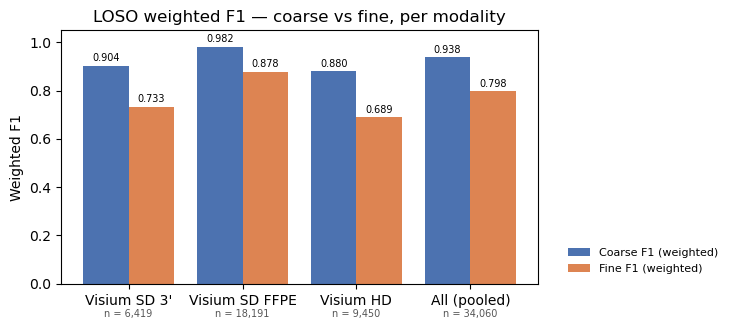

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.4))

x         = np.arange(len(overall))
fine_w    = overall['fine_f1_weighted'].astype(float).values
coarse_w  = overall['coarse_f1_weighted'].astype(float).values
labels    = {
    'SD_3prime': "Visium SD 3'",
    'SD_FFPE':   'Visium SD FFPE',
    'HD':        'Visium HD',
    'all':       'All (pooled)',
}
tick_labels = [labels.get(m, m) for m in overall['modality']]

ax.bar(x - 0.2, coarse_w, 0.4, color='#4c72b0', label='Coarse F1 (weighted)')
ax.bar(x + 0.2, fine_w,   0.4, color='#dd8452', label='Fine F1 (weighted)')
for xi, c, f in zip(x, coarse_w, fine_w):
    ax.text(xi - 0.2, c + 0.01, f'{c:.3f}', ha='center', va='bottom', fontsize=7)
    ax.text(xi + 0.2, f + 0.01, f'{f:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(tick_labels)
ax.set_ylim(0, 1.05); ax.set_ylabel('Weighted F1')
ax.set_title('LOSO weighted F1 — coarse vs fine, per modality')
ax.legend(loc='lower right', bbox_to_anchor=(1.4, 0.0), fontsize=8, frameon=False)
for xi, m in zip(x, overall['modality']):
    n = int(overall.loc[overall['modality'] == m, 'fine_n_spots'].iloc[0])
    ax.text(xi, -0.1, f'n = {n:,}', ha='center', va='top',
            fontsize=7, color='#555', transform=ax.get_xaxis_transform())
plt.tight_layout()
plt.savefig(f'{figdir}/TissuTypist_loso-accuracy_default_overall-F1-per-modality.pdf', bbox_inches="tight",dpi=300)
plt.show()

## 3 — Per-niche F1 vs section coverage

Cross-references per-niche F1 with the number of distinct training sections
containing each niche (out of 14).

In [20]:
from tissuetypist.evaluation.loso import _build_label_taxonomy
tax = _build_label_taxonomy(spec)

# Canonicalise GT: gt_label_remap + legacy intermediate map (so the row label
# matches the resolution-aware F1 report).
pooled['gt_canon'] = remap_ground_truth(pooled['ground_truth_fine'].astype(str), spec)
pooled['gt_canon'] = pooled['gt_canon'].map(lambda x: tax['legacy_map'].get(x, x))

coverage = (pooled.groupby('gt_canon')
                  .agg(n_sections=('section_id', 'nunique'),
                       n_donors  =('donor',      'nunique'),
                       n_mods    =('modality',   'nunique'),
                       n_spots   =('spot_id',    'count'))
                  .reset_index().rename(columns={'gt_canon': 'niche'}))

per_niche = aggregate_per_niche_metrics(pooled, spec, mode=MODE)
per_niche = per_niche[~per_niche['niche'].isin(['accuracy', 'macro avg', 'weighted avg'])]
per_niche = per_niche[per_niche['support'].astype(float) > 0]

merged = coverage.merge(per_niche[['niche', 'f1-score', 'support']], on='niche')
merged['coarse'] = merged['niche'].map(leaf_to_coarse).fillna(merged['niche'])
merged = merged.sort_values(['n_sections', 'f1-score'], ascending=[True, True]).reset_index(drop=True)
merged.head()

,niche,n_sections,n_donors,n_mods,n_spots,f1-score,support,coarse
0,Lymph node,1,1,1,20,0.000000,20.0,Lymph node
1,Ductus arteriosus,2,2,1,169,0.551320,168.0,Vasculature
2,Sinoatrial region,3,3,1,18,0.434783,18.0,Pacemaker conduction system
3,SA node - Tail,4,3,1,97,0.486486,97.0,Pacemaker conduction system
4,Atrium - Transitional,4,3,1,100,0.576271,98.0,Atrium


In [21]:
r_pearson  = merged[['n_sections', 'f1-score']].corr().iloc[0, 1]
r_spearman = merged[['n_sections', 'f1-score']].corr(method='spearman').iloc[0, 1]
print(f'Pearson r  = {r_pearson:+.3f}   (n = {len(merged)} niches)')
print(f'Spearman r = {r_spearman:+.3f}')

Pearson r  = +0.583   (n = 22 niches)
Spearman r = +0.484


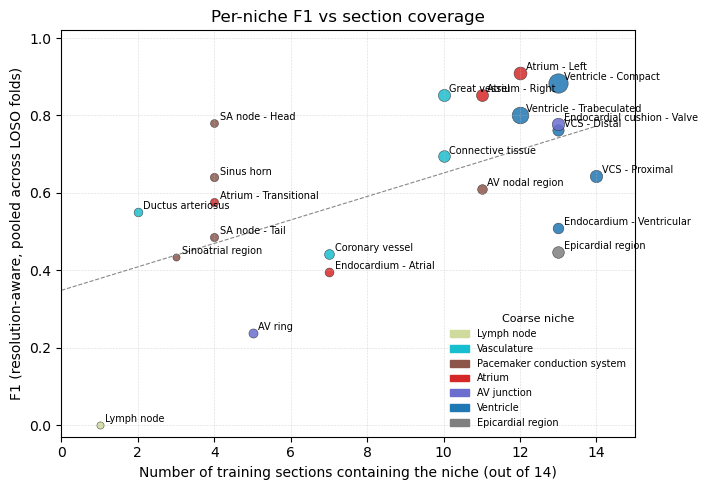

In [23]:
fig, ax = plt.subplots(figsize=(7.2, 5))
for _, r in merged.iterrows():
    ax.scatter(r['n_sections'], r['f1-score'],
               s=20 + 1.5 * (r['support'] ** 0.5),
               color=palette.get(r['coarse'], '#bbbbbb'),
               edgecolors='#333', linewidths=0.4, alpha=0.85)
    ax.annotate(r['niche'], (r['n_sections'], r['f1-score']),
                xytext=(4, 2), textcoords='offset points', fontsize=7)

z  = np.polyfit(merged['n_sections'], merged['f1-score'], 1)
xs = np.linspace(0, 14, 50)
ax.plot(xs, np.polyval(z, xs), '--', color='#888', linewidth=0.8,
        label=f'linear fit (Pearson r = {r_pearson:+.2f})')

ax.set_xlim(0, 15); ax.set_ylim(-0.03, 1.02)
ax.set_xlabel('Number of training sections containing the niche (out of 14)')
ax.set_ylabel('F1 (resolution-aware, pooled across LOSO folds)')
ax.set_title('Per-niche F1 vs section coverage')
ax.grid(linestyle=':', linewidth=0.4, color='#bbb')

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=palette.get(c, '#ccc'), label=c)
           for c in dict.fromkeys(merged['coarse'])]
ax.legend(handles=handles, loc='lower right', fontsize=7, frameon=False,
          title='Coarse niche', title_fontsize=8)
plt.tight_layout()
plt.savefig(f'{figdir}/TissuTypist_loso-accuracy_default_per-nichF1-vs-section-coverage.pdf', bbox_inches="tight",dpi=300)
plt.show()

## 4 — Per sub-model confusion matrices

One row-normalised heatmap per non-terminal coarse niche. Each cell 
*[i, j]* = fraction of spots whose ground truth is row class *i* that the
model predicted as column class *j*. Diagonal = recall.

In [24]:
cms = build_confusion_matrices(pooled, spec, mode=MODE)
submodel_keys = sorted(k for k in cms if k.startswith('submodel__'))
print('Sub-models with CMs:', [k.replace('submodel__', '') for k in submodel_keys])

Sub-models with CMs: ['AV junction', 'Atrium', 'Pacemaker conduction system', 'Vasculature', 'Ventricle']


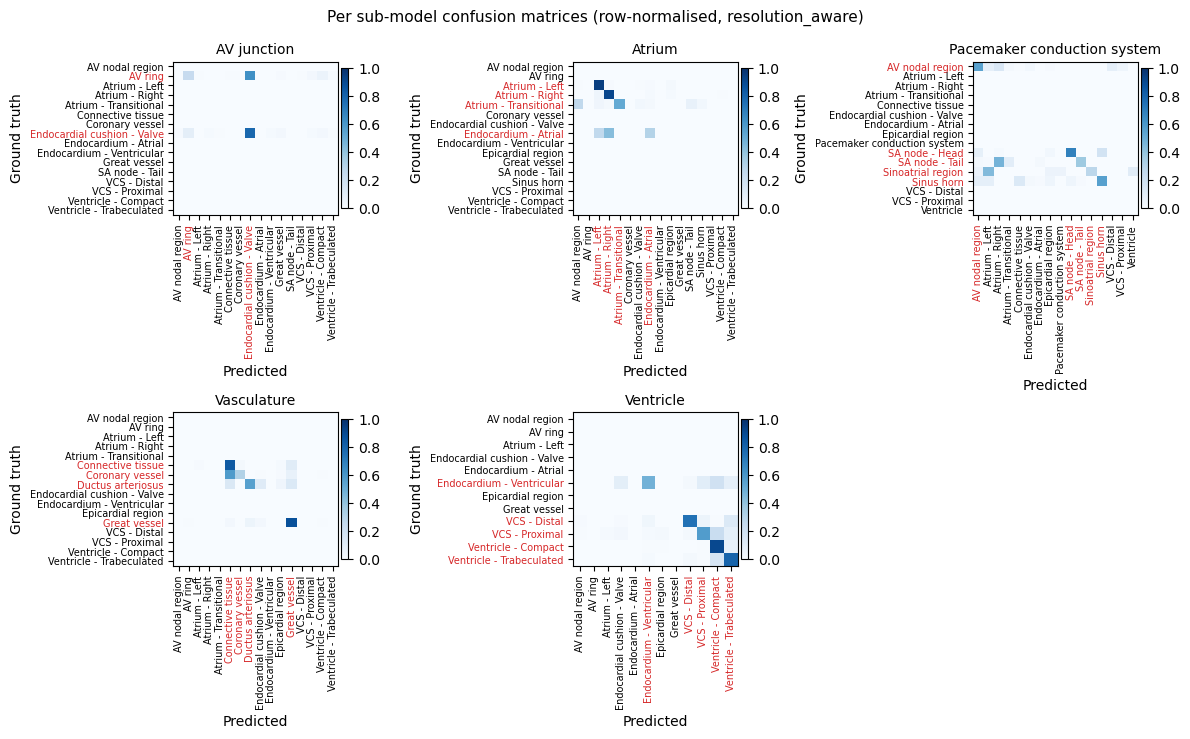

In [45]:
import math

# Labels to highlight (red) on each sub-model's tick labels.
HIGHLIGHT = {
    'AV junction': {'AV ring', 'Endocardial cushion - Valve'},
    'Atrium':      {'Endocardium - Atrial', 'Atrium - Transitional', 'Atrium - Left', 'Atrium - Right'},
    'Vasculature': {'Coronary vessel', 'Ductus arteriosus', 'Great vessel', 'Connective tissue'},
    'Pacemaker conduction system': {'Sinoatrial region', 'SA node - Tail', 'SA node - Head', 'Sinus horn',
                                    'AV nodal region'
                                   },
    'Ventricle':   {'Endocardium - Ventricular', 'VCS - Proximal', 'VCS - Distal',
                    'Ventricle - Compact', 'Ventricle - Trabeculated'},
}
HIGHLIGHT_COLOUR = '#d62728'   # red, matches the cardiac Atrium palette

ncols = min(3, len(submodel_keys))
nrows = math.ceil(len(submodel_keys) / ncols)
max_dim = max(len(cms[k]) for k in submodel_keys)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows), squeeze=False)

for i, key in enumerate(submodel_keys):
    parent = key.replace('submodel__', '')
    cm     = cms[key]
    r, c   = divmod(i, ncols)
    ax     = axes[r][c]
    im     = ax.imshow(cm.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    labels = cm.index.tolist()
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground truth')
    ax.set_title(parent, fontsize=10)

    # Highlight focus labels: red on both x and y tick labels.
    highlight = HIGHLIGHT.get(parent, set())
    if highlight:
        for tick in ax.get_xticklabels():
            if tick.get_text() in highlight:
                tick.set_color(HIGHLIGHT_COLOUR)
                # tick.set_fontweight('bold')
        for tick in ax.get_yticklabels():
            if tick.get_text() in highlight:
                tick.set_color(HIGHLIGHT_COLOUR)
                # tick.set_fontweight('bold')

for j in range(len(submodel_keys), nrows * ncols):
    r, c = divmod(j, ncols); axes[r][c].axis('off')

fig.suptitle('Per sub-model confusion matrices (row-normalised, resolution_aware)', fontsize=11, y=1.08)
plt.tight_layout(rect=(0, 0, 1, 1.1))
plt.savefig(f'{figdir}/TissuTypist_loso-accuracy_default_per-submodel-confusion-mtx.pdf', bbox_inches="tight",dpi=300)
plt.show()

Permutation test (κ): 100%|█████████████| 1000/1000 [00:25<00:00, 39.93it/s]


n spots evaluated:     34,037
n classes evaluated:   21
Cohen's kappa:         0.7501
  permutation p-value: < 1.0e-03  (n_perm = 1000)
  null mean (95% CI):  +0.0001  [-0.0048, +0.0048]
Accuracy:              0.8050
Macro F1:              0.6370
Weighted F1:           0.7983


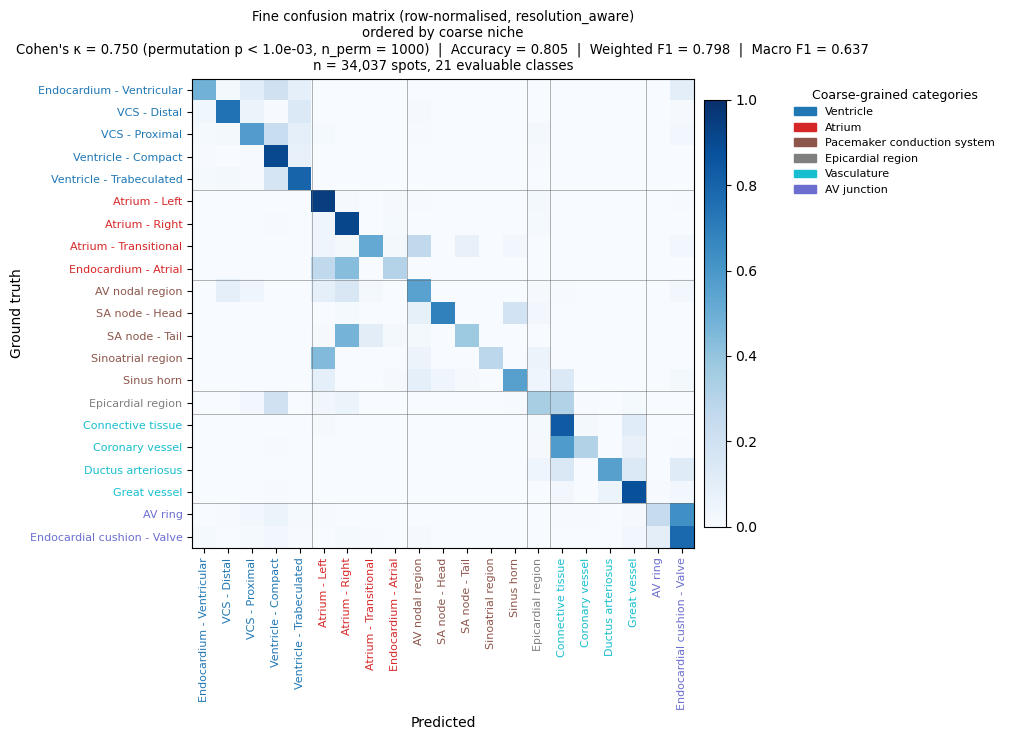

In [59]:
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
from tqdm import tqdm

from tissuetypist.evaluation.loso import _apply_scoring_mode
from tissuetypist.evaluation.metrics import remap_ground_truth

# Labels to drop from both axes (no real GT, or LOSO artefacts).
DROP_LABELS = {'Pacemaker conduction system', 'Lymph node', 'Ventricle'}

fine_cm = cms.get('fine')
assert fine_cm is not None, 'Fine CM not in `cms` — re-run build_confusion_matrices.'

# ── 1. Drop unwanted labels from the CM. ──────────────────────────────────
keep = [l for l in fine_cm.index if l not in DROP_LABELS]
fine_cm = fine_cm.loc[keep, keep]

# ── 2. Order labels by parent coarse niche. ───────────────────────────────
coarse_order = {c: i for i, c in enumerate(spec.coarse_niches)}
def _sort_key(label):
    coarse = leaf_to_coarse.get(label, label)
    return (coarse_order.get(coarse, 99), label)
ordered = sorted(fine_cm.index, key=_sort_key)
fine_cm = fine_cm.loc[ordered, ordered]

# ── 3. Per-label colour from coarse parent. ───────────────────────────────
label_colour = {l: palette.get(leaf_to_coarse.get(l, l), '#888') for l in ordered}

# ══════════════════════════════════════════════════════════════════════════
# 4. Statistical tests (computed on the SAME spots that built the matrix)
# ══════════════════════════════════════════════════════════════════════════

# Reproduce the resolution_aware transformation that build_confusion_matrices
# applied internally, then drop the same labels we dropped from the matrix.
sub  = pooled.dropna(subset=['tt_final_label', 'ground_truth_fine']).copy()
gt   = remap_ground_truth(sub['ground_truth_fine'].astype(str), spec)
pred = sub['tt_final_label'].astype(str)
y_true_full, y_pred_full = _apply_scoring_mode(gt, pred, spec, mode='resolution_aware')

mask = ~y_true_full.isin(DROP_LABELS) & ~y_pred_full.isin(DROP_LABELS)
y_true = y_true_full[mask].astype(str).values
y_pred = y_pred_full[mask].astype(str).values

# Aggregate metrics — same set sklearn returns from classification_report.
kappa       = cohen_kappa_score(y_true, y_pred)
acc         = accuracy_score(y_true, y_pred)
macro_f1    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Permutation test for kappa: shuffle predictions, recompute kappa.
# One-sided p-value = P(perm_kappa >= observed_kappa).
def permutation_test_kappa(y_true, y_pred, n_perm=1000, random_state=42,
                           show_progress=True):
    rng        = np.random.default_rng(random_state)
    observed   = cohen_kappa_score(y_true, y_pred)
    y_pred_arr = np.asarray(y_pred)
    permuted   = np.empty(n_perm)
    it = range(n_perm)
    if show_progress:
        it = tqdm(it, desc='Permutation test (κ)')
    for i in it:
        permuted[i] = cohen_kappa_score(y_true, rng.permutation(y_pred_arr))
    p_value = (np.sum(permuted >= observed) + 1) / (n_perm + 1)
    return observed, permuted, p_value

N_PERM = 1000
obs_kappa, perm_kappas, p_perm = permutation_test_kappa(
    y_true, y_pred, n_perm=N_PERM, random_state=42,
)

# Format p-value: anything below 1/(n_perm+1) is reported as "<", per
# permutation-test convention (you can't resolve smaller p with this n_perm).
def _fmt_p(p, n_perm):
    floor = 1.0 / (n_perm + 1)
    if p <= floor:
        return f"< {floor:.1e}"
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.3f}"

print(f"n spots evaluated:     {len(y_true):,}")
print(f"n classes evaluated:   {len(set(y_true) | set(y_pred))}")
print(f"Cohen's kappa:         {kappa:.4f}")
print(f"  permutation p-value: {_fmt_p(p_perm, N_PERM)}  (n_perm = {N_PERM})")
print(f"  null mean (95% CI):  {perm_kappas.mean():+.4f}  "
      f"[{np.quantile(perm_kappas, 0.025):+.4f}, "
      f"{np.quantile(perm_kappas, 0.975):+.4f}]")
print(f"Accuracy:              {acc:.4f}")
print(f"Macro F1:              {macro_f1:.4f}")
print(f"Weighted F1:           {weighted_f1:.4f}")

# ── 5. Plot. ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10.5, 7.5))
im = ax.imshow(fine_cm.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

n = len(ordered)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(ordered, rotation=90, fontsize=8)
ax.set_yticklabels(ordered, fontsize=8)

for tick in ax.get_xticklabels():
    tick.set_color(label_colour.get(tick.get_text(), '#000'))
for tick in ax.get_yticklabels():
    tick.set_color(label_colour.get(tick.get_text(), '#000'))

prev_coarse = None
for i, label in enumerate(ordered):
    coarse = leaf_to_coarse.get(label, label)
    if prev_coarse is not None and coarse != prev_coarse:
        ax.axhline(i - 0.5, color='#666', linewidth=0.5, alpha=0.7)
        ax.axvline(i - 0.5, color='#666', linewidth=0.5, alpha=0.7)
    prev_coarse = coarse

ax.set_xlabel('Predicted')
ax.set_ylabel('Ground truth')

# Title now carries the headline stats — self-documenting figure.
title_main = ('Fine confusion matrix (row-normalised, resolution_aware)\n'
              'ordered by coarse niche')
title_stats = (f"Cohen's κ = {obs_kappa:.3f} "
               f"(permutation p {_fmt_p(p_perm, N_PERM)}, n_perm = {N_PERM})  |  "
               f"Accuracy = {acc:.3f}  |  "
               f"Weighted F1 = {weighted_f1:.3f}  |  Macro F1 = {macro_f1:.3f}\n"
               f"n = {len(y_true):,} spots, "
               f"{len(set(y_true) | set(y_pred))} evaluable classes")
ax.set_title(f"{title_main}\n{title_stats}", fontsize=9.5)

# Coarse-niche legend (mirrors the scatter plot).
unique_coarse = list(dict.fromkeys(leaf_to_coarse.get(l, l) for l in ordered))
handles = [mpatches.Patch(color=palette.get(c, '#ccc'), label=c)
           for c in unique_coarse]
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.18, 1.0),
          fontsize=8, frameon=False, title='Coarse-grained categories',
          title_fontsize=9)

plt.tight_layout()
plt.savefig(f'{figdir}/TissuTypist_loso-accuracy_default_fine-confusionmatrix-by-coarse.pdf',
            bbox_inches='tight', dpi=300)
plt.show()